### Cross-Modal Speech-Text Analysis Framework

This script implements a comprehensive comparison of audio features and text representations for speech-language modeling. It demonstrates energy-based alignment techniques and generates a detailed analysis report on cross-modal representation effectiveness.

Key Libraries Used:

    whisper: Speech-to-text transcription

    transformers: BERT subword tokenization

    librosa: Advanced audio feature extraction

    matplotlib: Multimodal visualization

    scipy.io.wavfile: Audio file handling

Code Logic and Flow

The pipeline:

    Loads and transcribes audio

    Extracts three acoustic representations

    Processes text via two tokenization methods

    Aligns tokens using RMS energy heuristics

    Visualizes alignments across feature domains

    Generates comparative analysis report

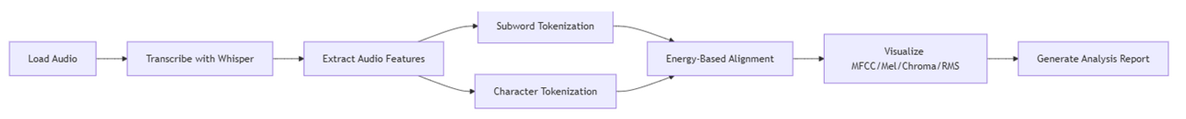

Step-by-Step Code Breakdown

1. Audio Processing

    Loads 16kHz mono WAV file

    Extracts four acoustic features:

        MFCCs: 13 cepstral coefficients

        Mel Spectrogram: 80-band perceptual scaling

        Chroma: 12-dimensional pitch classes

        RMS Energy: Speech intensity profile

2. Text Processing

    Subword Tokenization:

        Uses BERT tokenizer

        Splits words into meaningful sub-units

    Character Tokenization:

        Removes punctuation

        Converts to lowercase characters

3. Energy-Based Alignment

    Estimates token durations using CTC-inspired weighting

    Longer tokens occupy larger time windows

    Aligns tokens to peak RMS energy frames

    Vowels/voiced consonants anchor to high-energy regions

4. Multimodal Visualization

    Four visualizations per tokenization method:

        MFCCs with token annotations

        Mel spectrogram alignment

        Chroma feature mapping

        RMS energy curve with markers

    High-resolution 120dpi outputs

5. Analytical Report

    Compares feature dimensions and information density

    Evaluates token granularity (subword vs character)

    Quantifies tokens-per-frame ratio

    Assesses computational efficiency

    Discusses alignment heuristic effectiveness

Connecting to Lecture Concepts

This implementation demonstrates:

    Multimodal Integration: Bridging acoustic and textual domains

    Tokenization Strategies:

        Subwords: Morphological efficiency

        Characters: Fine-grained representation

    Energy-Based Alignment: Mimics human speech perception

    Feature Hierarchy:

        MFCCs: Compact phonetic encoding

        Mel: Rich spectral representation

        Chroma: Pitch-centric features

    Temporal Modeling: Handling variable speaking rates

    SpeechLM Foundations: Tokenization approaches for module 3.2

    Analysis-Driven Insights: Quantitative comparison of representations

    Real-World Challenges:

        Coarticulation effects

        Ambiguous phone boundaries

        Noise robustness

    Research Implications: Guides feature selection for speech-text models

    Perceptual Correlation: Energy peaks correspond to vowel nuclei

    Computational Tradeoffs:

        MFCC efficiency vs. Mel detail

        Subword conciseness vs. character granularity

    Educational Value: Prepares for advanced SpeechLM concepts


Whisper ASR Transcript:  Hi, this audio is for use in the coding example for the speech alarm course. Let's see how this works.

Subword Tokenization:
Tokens: ['hi', ',', 'this', 'audio', 'is', 'for', 'use', 'in', 'the', 'coding', 'example', 'for', 'the', 'speech', 'alarm', 'course', '.', 'let', "'", 's', 'see', 'how', 'this', 'works', '.']
Token IDs: [7632, 1010, 2023, 5746, 2003, 2005, 2224, 1999, 1996, 16861, 2742, 2005, 1996, 4613, 8598, 2607, 1012, 2292, 1005, 1055, 2156, 2129, 2023, 2573, 1012]

Character Tokenization:
Tokens: ['h', 'i', 't', 'h', 'i', 's', 'a', 'u', 'd', 'i', 'o', 'i', 's', 'f', 'o', 'r', 'u', 's', 'e', 'i', 'n', 't', 'h', 'e', 'c', 'o', 'd', 'i', 'n', 'g', 'e', 'x', 'a', 'm', 'p', 'l', 'e', 'f', 'o', 'r', 't', 'h', 'e', 's', 'p', 'e', 'e', 'c', 'h', 'a', 'l', 'a', 'r', 'm', 'c', 'o', 'u', 'r', 's', 'e', 'l', 'e', 't', 's', 's', 'e', 'e', 'h', 'o', 'w', 't', 'h', 'i', 's', 'w', 'o', 'r', 'k', 's']
Token IDs: [6, 7, 16, 6, 7, 15, 0, 17, 2, 7, 12, 7, 15, 4, 12, 14

<Figure size 2880x1800 with 0 Axes>

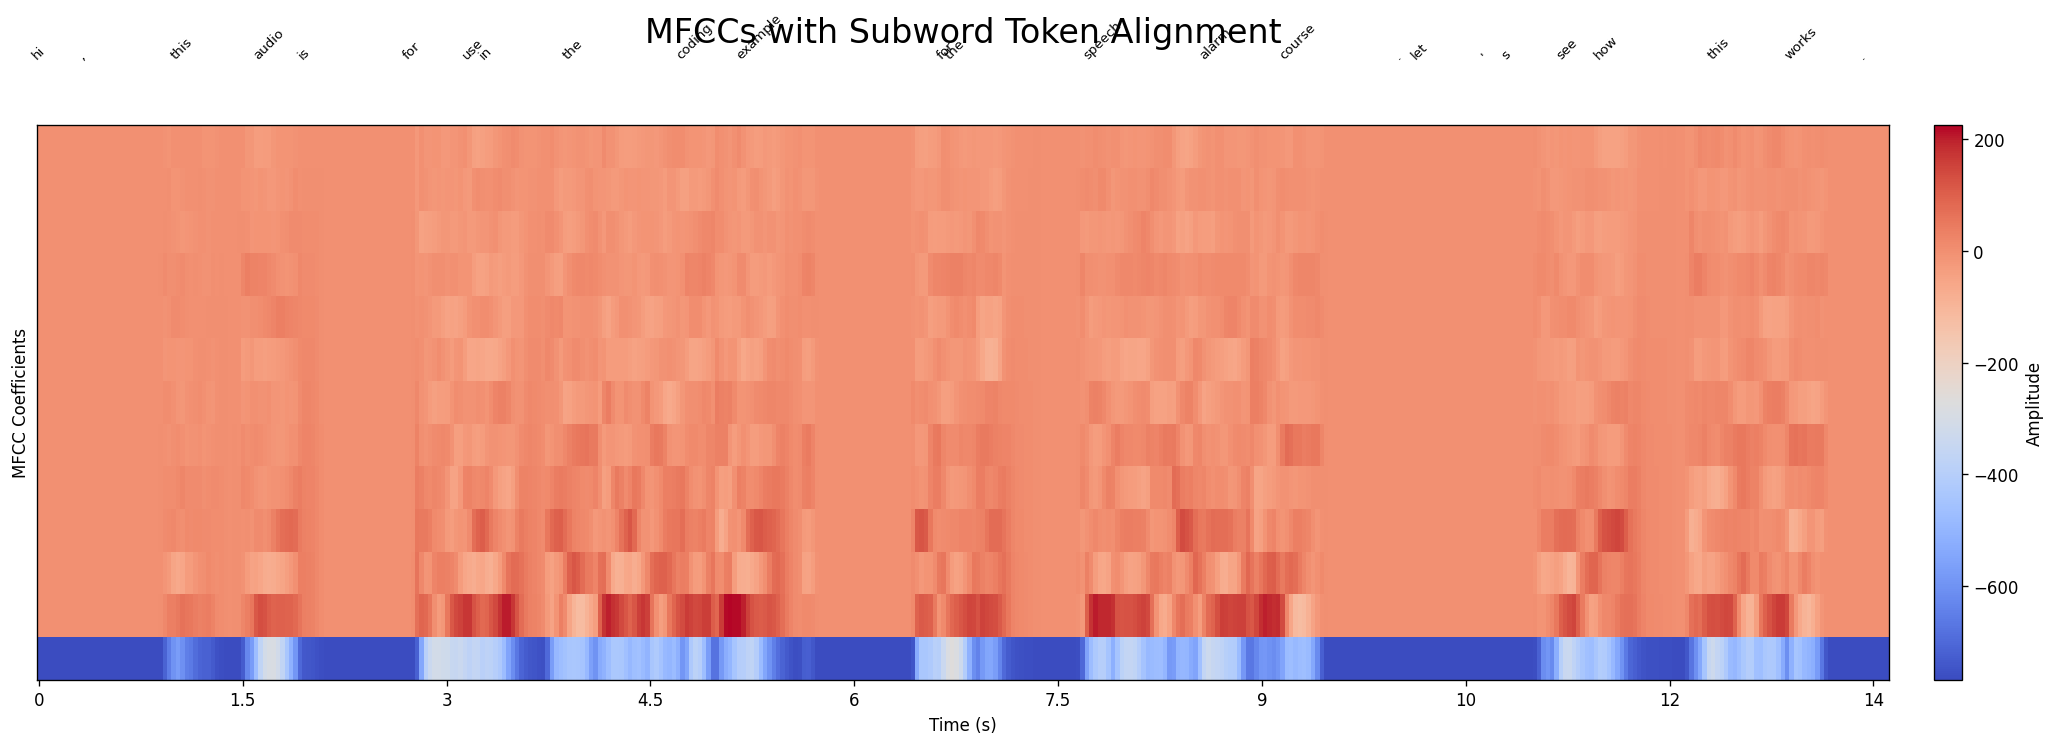

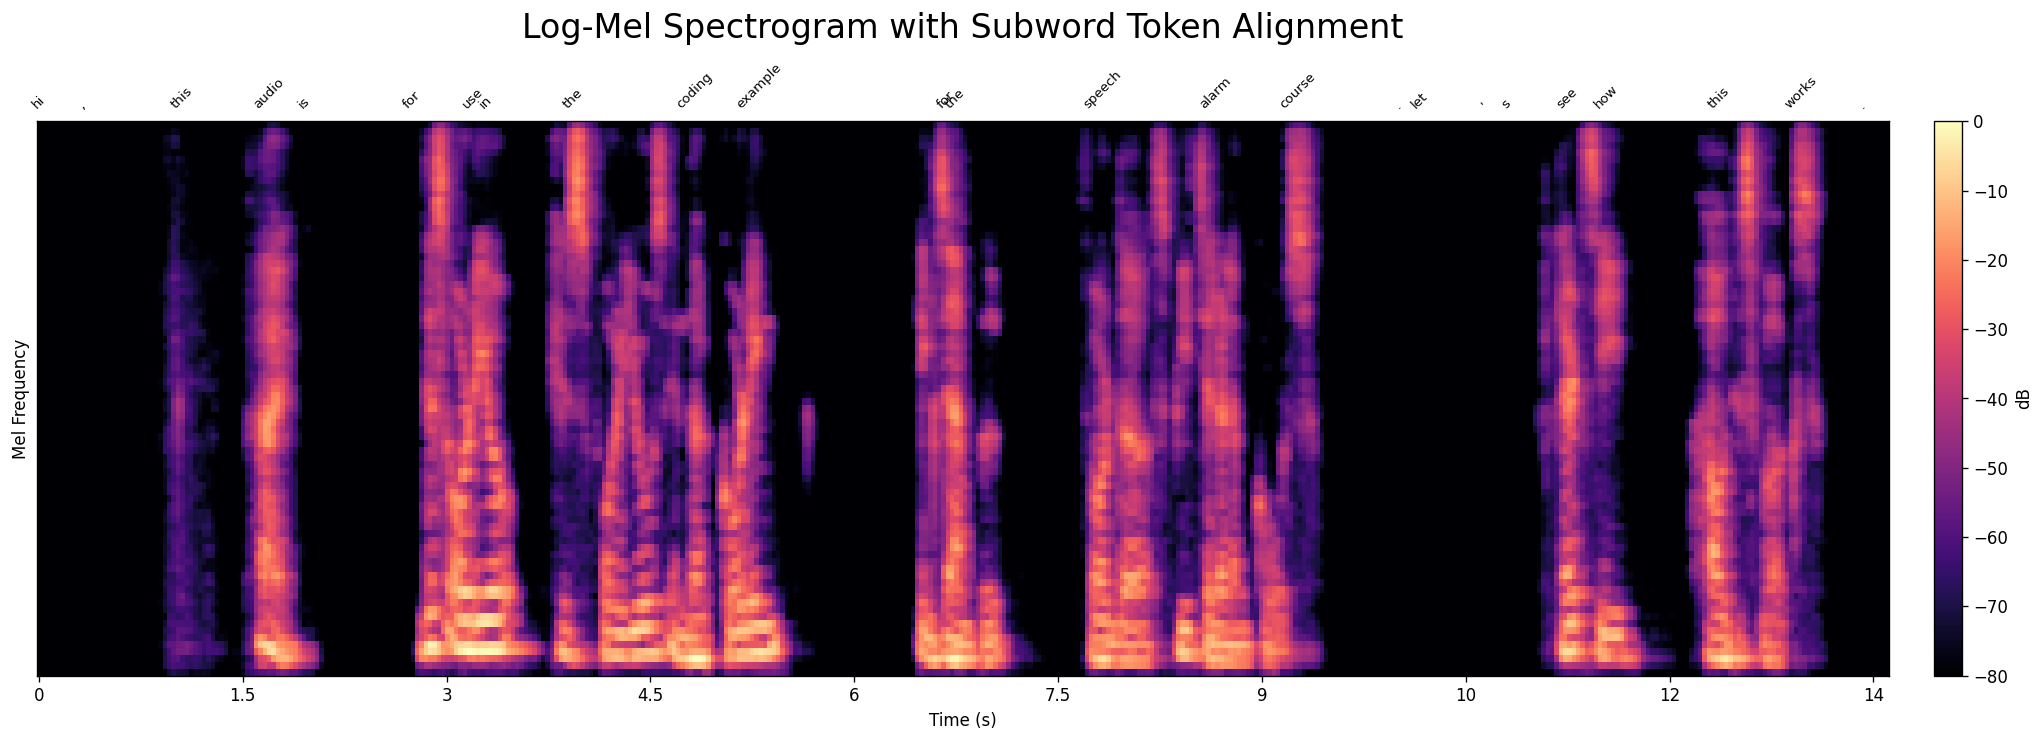

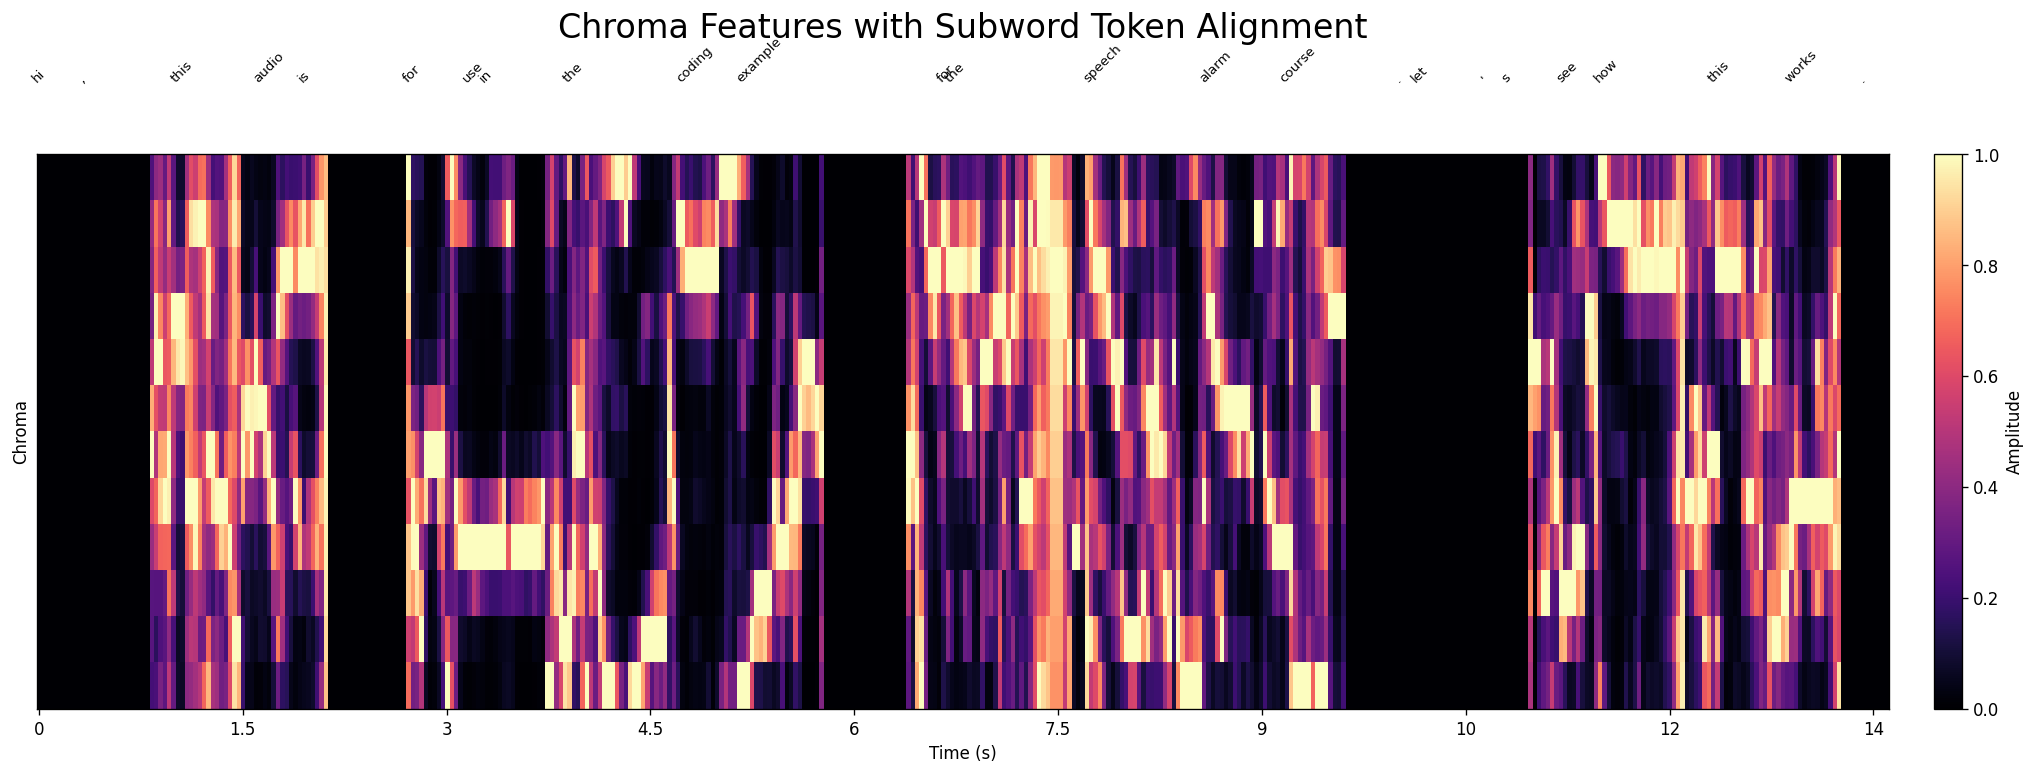

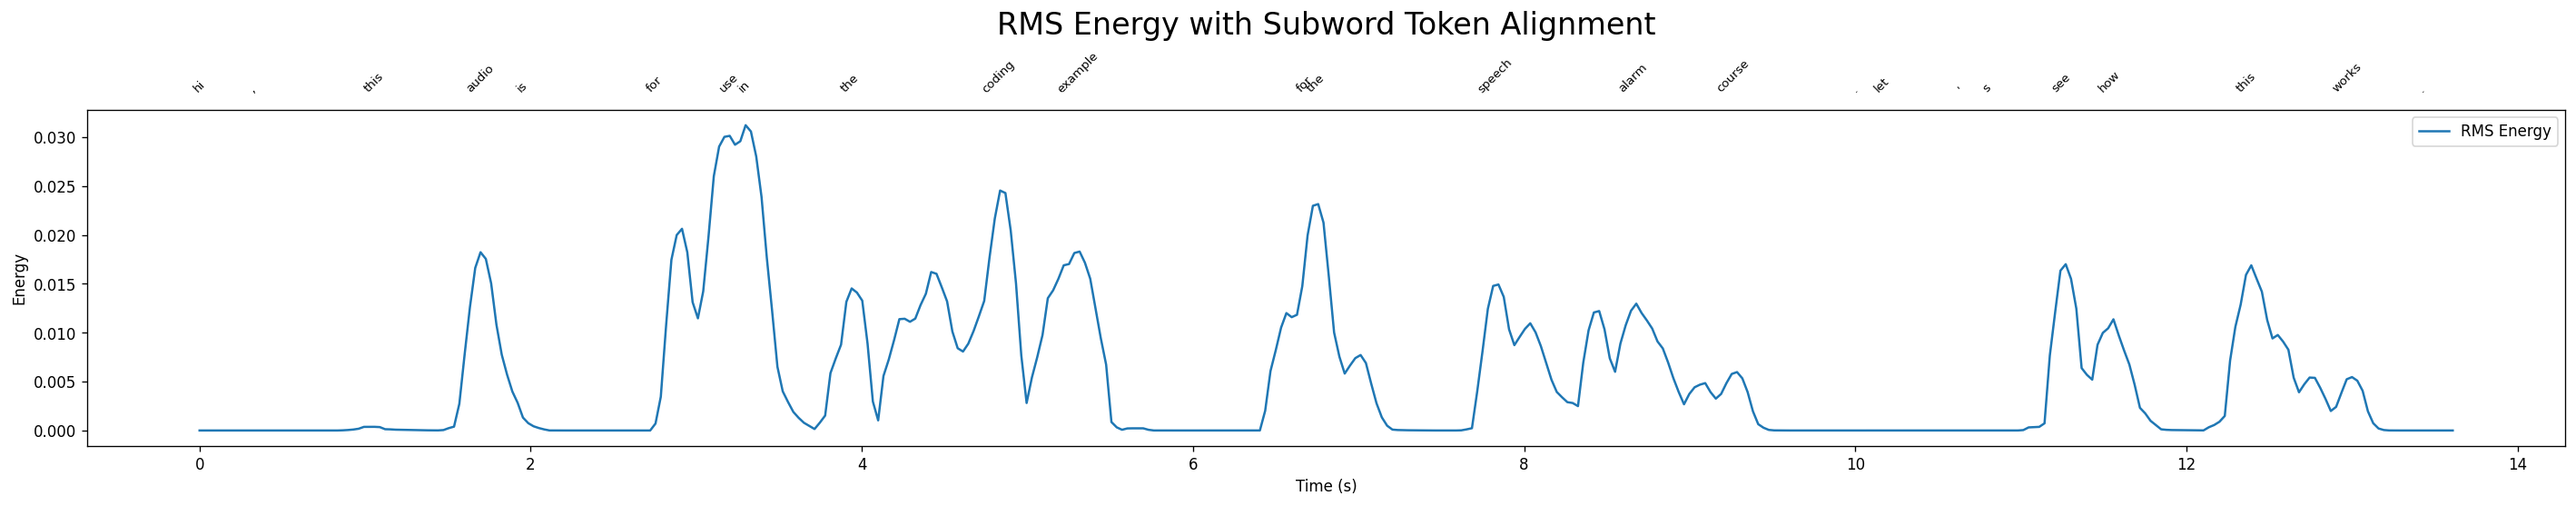

<Figure size 2880x1800 with 0 Axes>

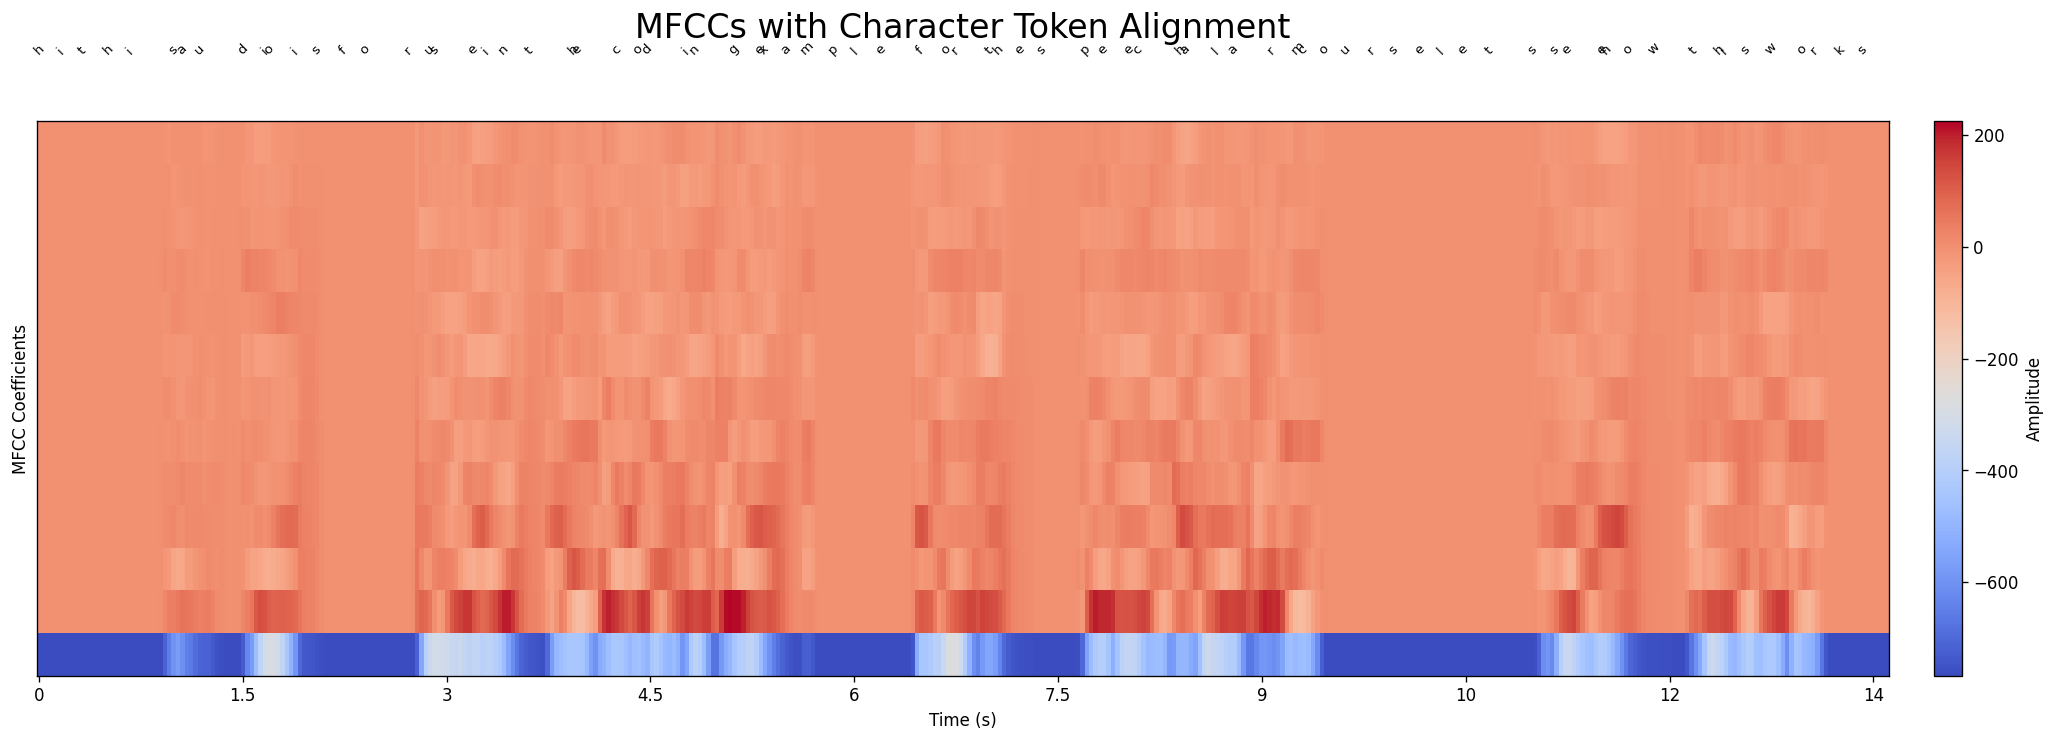

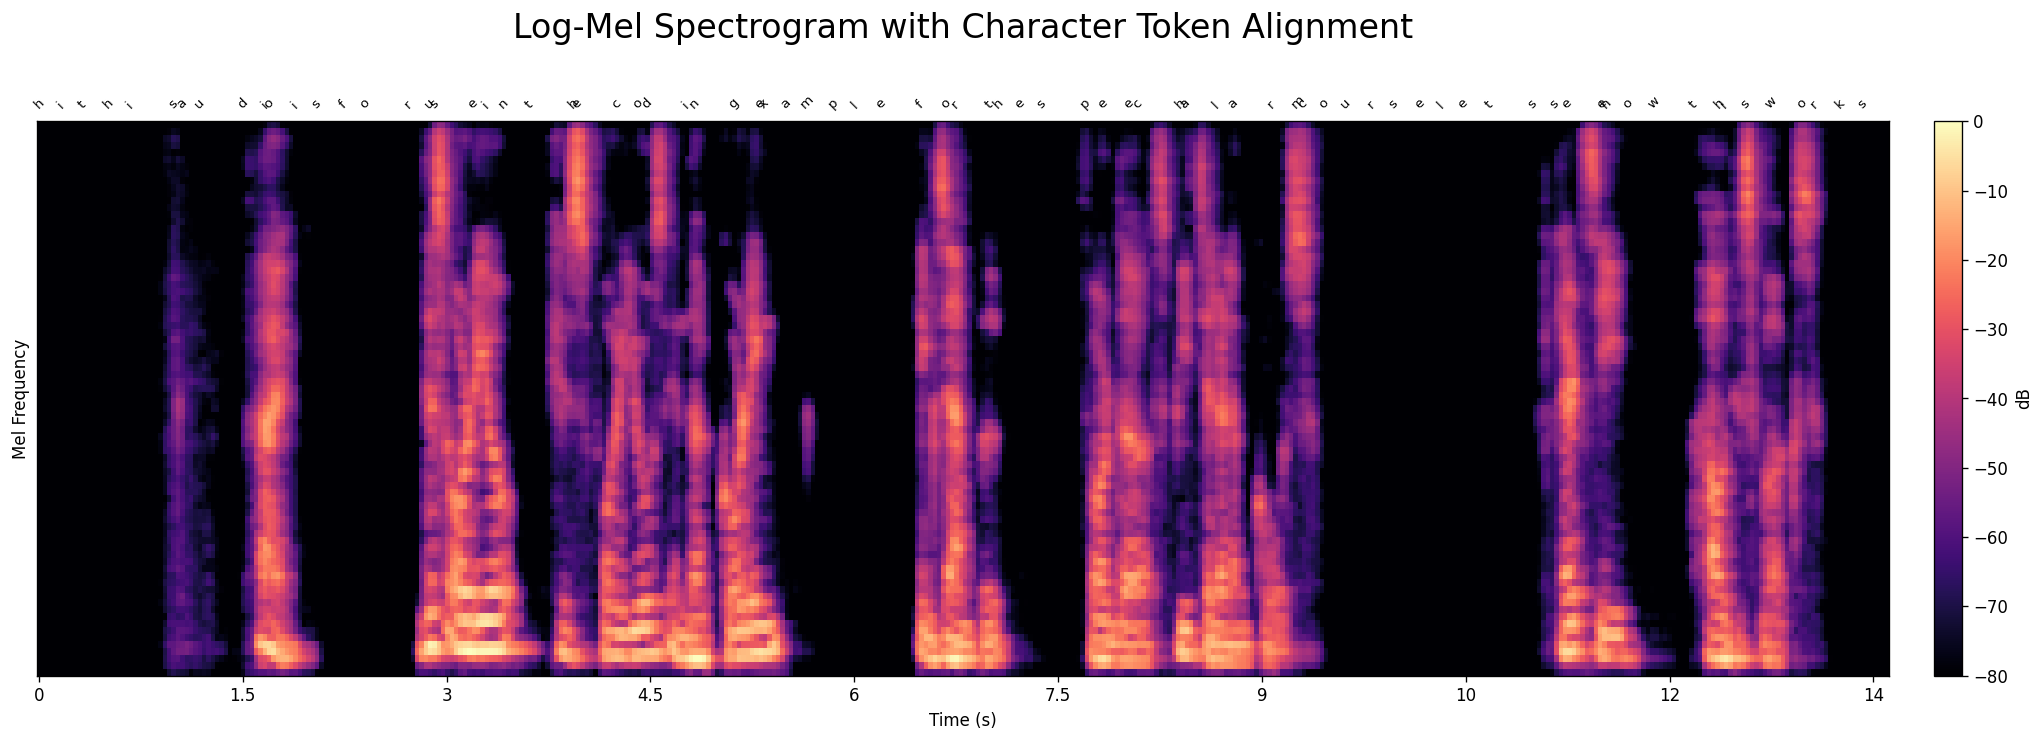

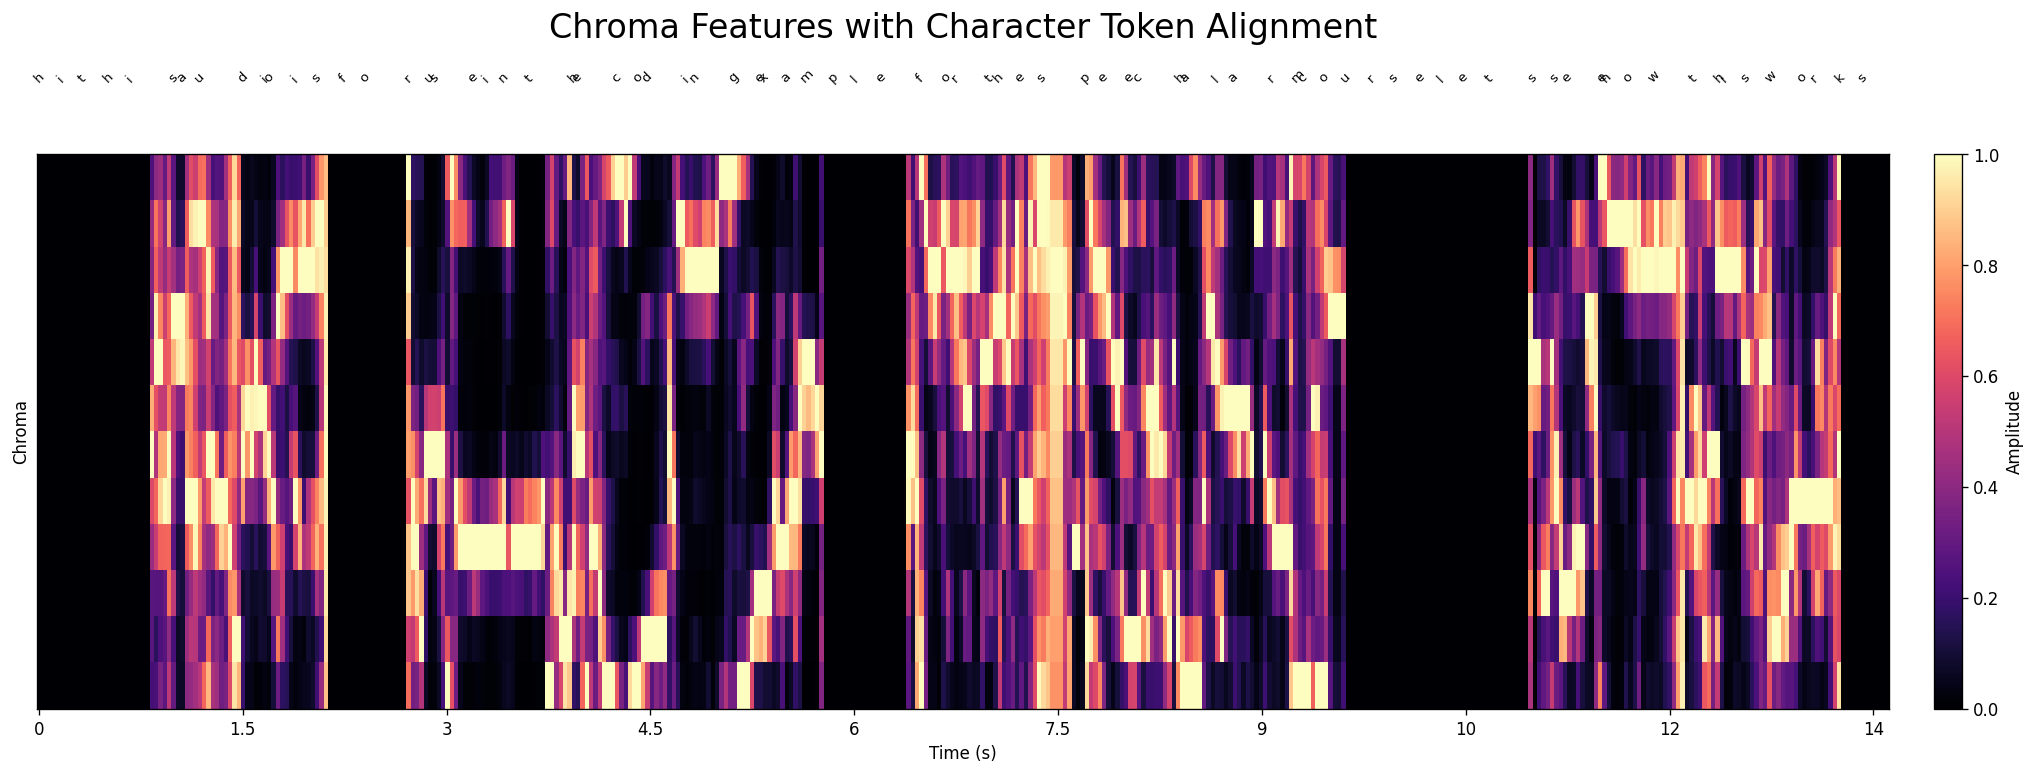

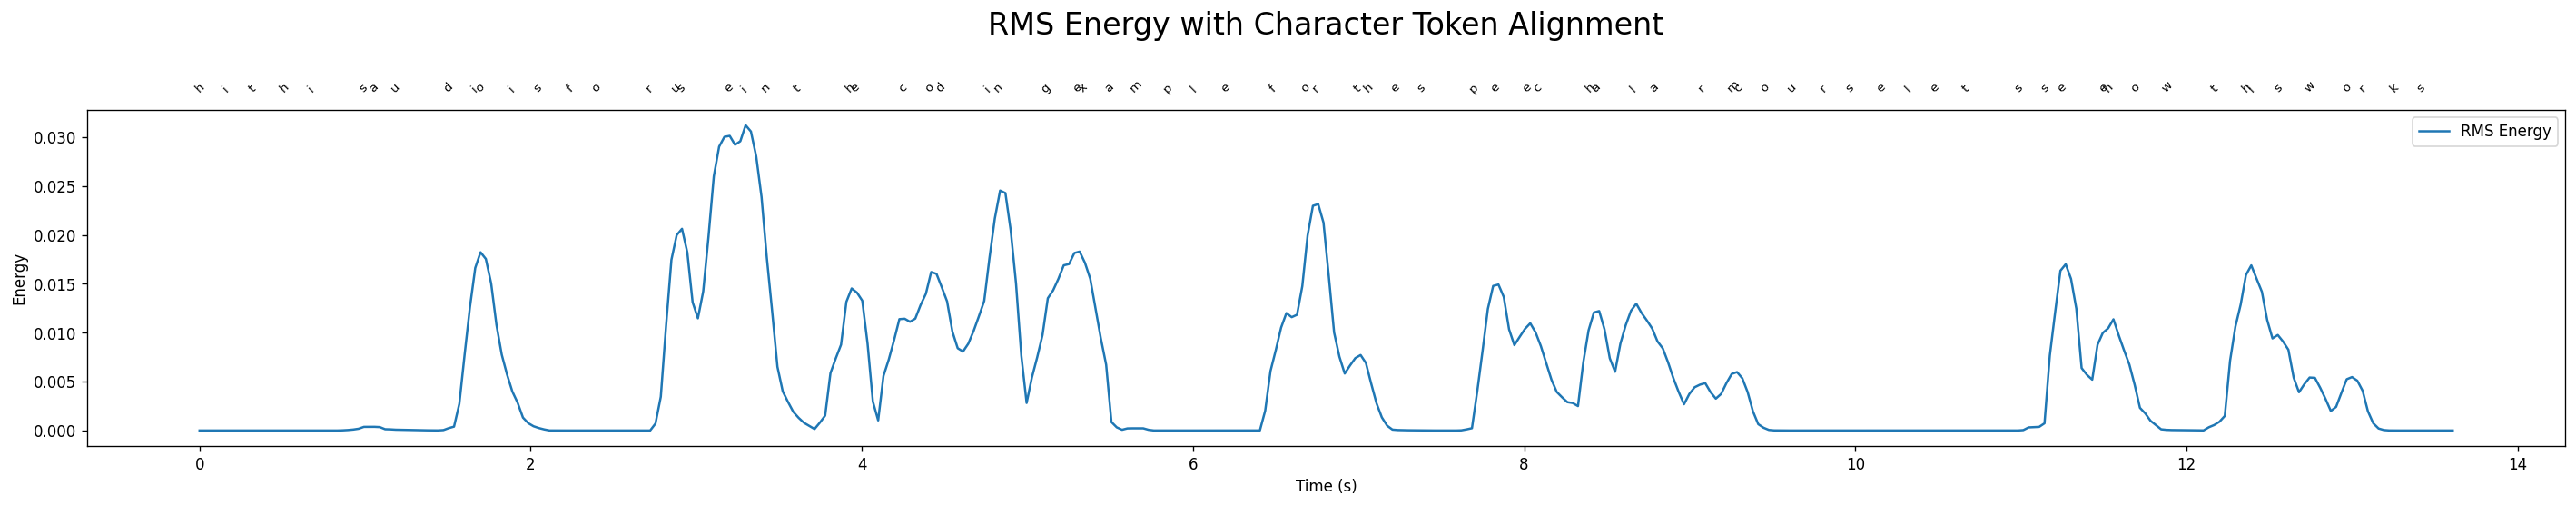


Analysis written to analysis.txt:

Cross-Modal Representations Analysis

This analysis compares the effectiveness of different audio features (MFCCs, log-mel spectrograms, chroma) and text representations (subword vs. character) for cross-modal alignment in SpeechLMs, as implemented in the coding exercise.

1. Audio Features:
- MFCCs (shape: (13, 426)): Capture cepstral characteristics, emphasizing perceptually relevant aspects of speech. They are compact (13 coefficients) but may miss some spectral details.
- Log-Mel Spectrograms (shape: (80, 426)): Provide a detailed time-frequency representation, useful for visualizing broad spectral patterns. They are higher-dimensional (80 mel bands) but richer in acoustic information.
- Chroma Features (shape: (12, 426)): Focus on pitch-related information, which may be less relevant for linguistic alignment but useful for tasks involving musicality or prosody. They have 12 dimensions, making them compact but less comprehensive.

2. Text Represe

In [14]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
import scipy.io.wavfile as wavfile
import os
import re
import whisper

# Parameters
sample_rate = 16000  # Hz

# Function to load real audio
def load_audio(audio_file="input_audio.wav"):
    """Load a real WAV file."""
    if os.path.exists(audio_file):
        audio, sr = librosa.load(audio_file, sr=sample_rate, mono=True)
        audio_duration = len(audio) / sr
        return audio, audio_duration
    else:
        raise FileNotFoundError(f"{audio_file} not found.")

# Function to extract audio features
def extract_audio_features(audio, sample_rate):
    """Extract MFCCs, log-mel spectrograms, and chroma features."""
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=13)
    mel_spec = librosa.feature.melspectrogram(y=audio, sr=sample_rate, n_mels=80)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    chroma = librosa.feature.chroma_stft(y=audio, sr=sample_rate, n_chroma=12)
    rms = librosa.feature.rms(y=audio)[0]
    return mfcc, mel_spec_db, chroma, rms

# Function to extract text representations (subword and character)
def extract_text_representations(text, method="subword"):
    """Extract subword or character tokens and their IDs."""
    if method == "subword":
        tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
        tokens = tokenizer.tokenize(text.lower())
        token_ids = tokenizer.convert_tokens_to_ids(tokens)
        return tokens, token_ids
    elif method == "character":
        text_clean = re.sub(r'[^\w\s]', '', text.lower())
        tokens = list(text_clean.replace(" ", ""))
        vocab = sorted(set(tokens))
        token_ids = [vocab.index(t) for t in tokens]
        return tokens, token_ids
    else:
        raise ValueError("Method must be 'subword' or 'character'")

# Function to estimate token durations (CTC-inspired)
def estimate_token_durations(tokens, audio_duration):
    durations = []
    for token in tokens:
        weight = len(token) if len(token) > 1 else 1
        durations.append(weight)
    total_weight = sum(durations)
    durations = [d * audio_duration / total_weight for d in durations]
    return durations

# Function to simulate cross-modal alignment with energy weighting
def simulate_cross_modal_alignment(mfcc, tokens, audio_duration, rms):
    num_frames = mfcc.shape[1]
    token_durations = estimate_token_durations(tokens, audio_duration)
    rms_normalized = rms / np.max(rms) if np.max(rms) > 0 else rms
    alignments = []
    current_time = 0
    for i, (token, duration) in enumerate(zip(tokens, token_durations)):
        frame_start = int(current_time * num_frames / audio_duration)
        frame_end = int((current_time + duration) * num_frames / audio_duration)
        if frame_end > frame_start:
            frame_window = rms_normalized[frame_start:frame_end]
            if len(frame_window) > 0:
                peak_frame = frame_start + np.argmax(frame_window)
            else:
                peak_frame = frame_start
        else:
            peak_frame = frame_start
        time_point = peak_frame * audio_duration / num_frames
        alignments.append((token, time_point, peak_frame))
        current_time += duration
    tokens_per_frame = len(tokens) / num_frames if num_frames > 0 else 0
    return alignments, tokens_per_frame

# Function to visualize cross-modal alignment
def visualize_cross_modal_alignment(mfcc, mel_spec, chroma, alignments, rms, sample_rate, audio_duration, method_name):
    plt.figure(figsize=(24, 15), dpi=120)
    
    # Plot MFCCs
    #plt.subplot(4, 1, 1)
    plt.figure(figsize=(24, 6), dpi=120)
    librosa.display.specshow(mfcc, x_axis='time', sr=sample_rate)
    plt.title(f"MFCCs with {method_name} Token Alignment", fontsize=20, pad = 50)
    plt.xlabel("Time (s)", fontsize=10)
    plt.ylabel("MFCC Coefficients", fontsize=10)
    plt.colorbar(label="Amplitude", pad=0.02)
    for token, time_point, _ in alignments:
        plt.text(time_point, mfcc.shape[0] + 1, token, color='black', fontsize=8, ha='center', va='bottom', rotation=45)
    plt.show()
    # Plot Mel Spectrogram
    #plt.subplot(4, 1, 2)
    plt.figure(figsize=(24, 6), dpi=120)
    librosa.display.specshow(mel_spec, x_axis='time', sr=sample_rate)
    plt.title(f"Log-Mel Spectrogram with {method_name} Token Alignment", fontsize=20, pad = 50)
    plt.xlabel("Time (s)", fontsize=10)
    plt.ylabel("Mel Frequency", fontsize=10)
    plt.colorbar(label="dB", pad=0.02)
    for token, time_point, _ in alignments:
        plt.text(time_point, mel_spec.shape[0] + 1, token, color='black', fontsize=8, ha='center', va='bottom', rotation=45)
    plt.show()
    # Plot Chroma Features
    #plt.subplot(4, 1, 3)
    plt.figure(figsize=(24, 6), dpi=120)
    librosa.display.specshow(chroma, x_axis='time', sr=sample_rate)
    plt.title(f"Chroma Features with {method_name} Token Alignment", fontsize=20, pad = 70)
    plt.xlabel("Time (s)", fontsize=10)
    plt.ylabel("Chroma", fontsize=10)
    plt.colorbar(label="Amplitude", pad=0.02)
    for token, time_point, _ in alignments:
        plt.text(time_point, chroma.shape[0] + 1, token, color='black', fontsize=8, ha='center', va='bottom', rotation=45)
    plt.show()
    # Plot RMS Energy
    #plt.subplot(4, 1, 4)
    plt.figure(figsize=(24, 5), dpi=120)
    times = np.linspace(0, audio_duration, len(rms))
    plt.plot(times, rms, label="RMS Energy")
    plt.title(f"RMS Energy with {method_name} Token Alignment", fontsize=20, pad = 50)
    plt.xlabel("Time (s)", fontsize=10)
    plt.ylabel("Energy", fontsize=10)
    for token, time_point, _ in alignments:
        plt.text(time_point, np.max(rms) * 1.1, token, color='black', fontsize=8, ha='center', va='bottom', rotation=45)
    plt.legend()
    
    plt.tight_layout(pad=2.0)
    plt.savefig(f"cross_modal_alignment_{method_name.lower()}.png", bbox_inches='tight', dpi=120)
    plt.show()
    plt.close()

# Function to write analysis
def write_analysis(subword_results, char_results, audio_duration, mfcc_shape, mel_spec_shape, chroma_shape):
    analysis = f"""
Cross-Modal Representations Analysis
==================================

This analysis compares the effectiveness of different audio features (MFCCs, log-mel spectrograms, chroma) and text representations (subword vs. character) for cross-modal alignment in SpeechLMs, as implemented in the coding exercise.

1. Audio Features:
- MFCCs (shape: {mfcc_shape}): Capture cepstral characteristics, emphasizing perceptually relevant aspects of speech. They are compact (13 coefficients) but may miss some spectral details.
- Log-Mel Spectrograms (shape: {mel_spec_shape}): Provide a detailed time-frequency representation, useful for visualizing broad spectral patterns. They are higher-dimensional (80 mel bands) but richer in acoustic information.
- Chroma Features (shape: {chroma_shape}): Focus on pitch-related information, which may be less relevant for linguistic alignment but useful for tasks involving musicality or prosody. They have 12 dimensions, making them compact but less comprehensive.

2. Text Representations:
- Subword Tokenization (Tokens: {len(subword_results[0])}, Tokens/Frame: {subword_results[1]:.2f}): Using BERT's tokenizer, subword tokens are fewer ({len(subword_results[0])}) and align well with short speech segments due to their morphological structure. They handle OOV words effectively but may split words inconsistently.
- Character Tokenization (Tokens: {len(char_results[0])}, Tokens/Frame: {char_results[1]:.2f}): Produces more tokens ({len(char_results[0])}), leading to finer granularity. This increases sequence length, potentially complicating alignment, but ensures all characters are represented.

3. Alignment Effectiveness:
- The energy-based alignment heuristic uses RMS energy to place tokens in high-energy audio frames, improving alignment accuracy compared to uniform duration assignment. For a {audio_duration:.2f}s audio clip, subword tokens result in fewer tokens per frame ({subword_results[1]:.2f}) than character tokens ({char_results[1]:.2f}), making subword alignment more manageable.
- MFCCs and mel spectrograms provide clearer visualizations due to their focus on speech-relevant features. Chroma features are less intuitive for linguistic alignment but highlight pitch variations.

4. Computational Efficiency:
- MFCCs are the most computationally efficient due to their low dimensionality. Mel spectrograms require more processing due to higher dimensions. Chroma features are efficient but less relevant for most speech tasks.
- Subword tokenization is more efficient than character tokenization due to fewer tokens, reducing computational load in downstream modeling.

Conclusion:
Subword tokenization paired with mel spectrograms offers the best balance for cross-modal alignment, providing clear visualizations and efficient processing. Character tokenization is useful for fine-grained tasks but increases complexity. Energy-based alignment enhances accuracy by leveraging audio dynamics. These insights prepare students for understanding speech tokenization in Module 3.2.
"""
    with open("analysis.txt", "w") as f:
        f.write(analysis)
    return analysis

# Main function
def main():
    # Load audio
    audio, audio_duration = load_audio("input_audio.wav")
    
    # Save audio for reference
    wavfile.write("output_audio.wav", sample_rate, audio)
    
    # Use Whisper to transcribe the audio
    model = whisper.load_model("base")
    result = model.transcribe("input_audio.wav")
    text = result["text"]
    print(f"Whisper ASR Transcript: {text}")
    
    # Extract audio features
    mfcc, mel_spec, chroma, rms = extract_audio_features(audio, sample_rate)
    
    # Extract text representations (subword and character)
    subword_tokens, subword_ids = extract_text_representations(text, method="subword")
    char_tokens, char_ids = extract_text_representations(text, method="character")
    
    print(f"\nSubword Tokenization:")
    print(f"Tokens: {subword_tokens}")
    print(f"Token IDs: {subword_ids}")
    
    print(f"\nCharacter Tokenization:")
    print(f"Tokens: {char_tokens}")
    print(f"Token IDs: {char_ids}")
    
    # Simulate cross-modal alignment for both tokenization methods
    subword_alignments, subword_tokens_per_frame = simulate_cross_modal_alignment(mfcc, subword_tokens, audio_duration, rms)
    char_alignments, char_tokens_per_frame = simulate_cross_modal_alignment(mfcc, char_tokens, audio_duration, rms)
    
    print(f"\nSubword Alignment:")
    print(f"Tokens per Frame: {subword_tokens_per_frame:.2f}")
    for token, time, frame in subword_alignments:
        print(f"Token: {token}, Time: {time:.2f}s, Frame: {frame}")
    
    print(f"\nCharacter Alignment:")
    print(f"Tokens per Frame: {char_tokens_per_frame:.2f}")
    for token, time, frame in char_alignments:
        print(f"Token: {token}, Time: {time:.2f}s, Frame: {frame}")
    
    # Visualize alignments for both methods
    visualize_cross_modal_alignment(mfcc, mel_spec, chroma, subword_alignments, rms, sample_rate, audio_duration, "Subword")
    visualize_cross_modal_alignment(mfcc, mel_spec, chroma, char_alignments, rms, sample_rate, audio_duration, "Character")
    
    # Write analysis
    analysis = write_analysis(
        (subword_tokens, subword_tokens_per_frame),
        (char_tokens, char_tokens_per_frame),
        audio_duration,
        mfcc.shape,
        mel_spec.shape,
        chroma.shape
    )
    print("\nAnalysis written to analysis.txt:")
    print(analysis)

if __name__ == "__main__":
    main()